# Week 7 Assignment: Feedforward Neural Networks, Activation Functions, and Backpropagation

**Dataset:** Heart Failure Clinical Records (UCI)  
**Focus:** Understanding nonlinear activation functions, hidden layer capacity, and learning dynamics  
**Student ID:** Chimeka Praise Reginald | 259059909


## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

**Library explanations:**

- `numpy` and `pandas`: numerical operations and tabular data handling.
- `matplotlib`: plotting learning curves, ROC curves, and comparison charts.
- `sklearn`: data splitting, scaling, logistic regression baseline, and evaluation metrics.
- `tensorflow / keras`: building and training feedforward neural networks (MLPs).
- `EarlyStopping`: halts training when validation loss stops improving, preventing unnecessary overfitting.
- Seeds are fixed at `42` for full reproducibility across runs.


## Load and Inspect the Dataset

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (299, 13)

Column names: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**Dataset context:**  
The Heart Failure Clinical Records dataset (UCI) contains **299 patient records** with **12 clinical features** and a binary target variable `DEATH_EVENT` (0 = survived, 1 = died).  
Clinical features include age, serum creatinine, ejection fraction, anaemia, diabetes, blood pressure, and others.


In [3]:
print("Missing values:", df.isna().sum().sum())
print("\nClass distribution:")
print(df["DEATH_EVENT"].value_counts())
print(f"\nClass balance: {df['DEATH_EVENT'].mean()*100:.1f}% deaths")

Missing values: 0

Class distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Class balance: 32.1% deaths


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


## Train / Validation / Test Split and Feature Scaling

In [5]:
X = df.drop(columns=["DEATH_EVENT"]).values
y = df["DEATH_EVENT"].values

print("Feature matrix shape:", X.shape)
print("Target vector shape: ", y.shape)

Feature matrix shape: (299, 12)
Target vector shape:  (299,)


In [6]:
# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: split temp equally into val and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "  Val:", X_val.shape, "  Test:", X_test.shape)
print("\nClass distribution - Train:", y_train.mean().round(3),
      " Val:", y_val.mean().round(3),
      " Test:", y_test.mean().round(3))

Train: (209, 12)   Val: (45, 12)   Test: (45, 12)

Class distribution - Train: 0.321  Val: 0.333  Test: 0.311


**Stratification** ensures that the proportion of `DEATH_EVENT = 1` is preserved in all three splits,  
which is critical with an imbalanced dataset (≈32% deaths). Without stratification, random chance could  
produce splits where one subset has very few positive examples, leading to misleading accuracy metrics.


In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   
X_val_s   = scaler.transform(X_val)       
X_test_s  = scaler.transform(X_test)     

print("Scaling applied. Mean of scaled training features:",
      np.abs(X_train_s.mean(axis=0)).mean().round(4))

Scaling applied. Mean of scaled training features: 0.0


**Why fit only on training data?**  
The `StandardScaler` computes the mean and standard deviation from the training set and applies the same  
parameters to the validation and test sets. Fitting the scaler on all data would cause **data leakage** —  
information from the future (test set) would contaminate the training statistics, producing overly optimistic results.


---
## Task 1: Logistic Regression vs MLP (One Hidden Layer)


### 1.1 Logistic Regression Baseline (No Hidden Layer)

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)

lr_train_preds = lr_model.predict(X_train_s)
lr_train_proba = lr_model.predict_proba(X_train_s)[:, 1]
lr_val_preds   = lr_model.predict(X_val_s)
lr_val_proba   = lr_model.predict_proba(X_val_s)[:, 1]

lr_train_acc = accuracy_score(y_train, lr_train_preds)
lr_train_auc = roc_auc_score(y_train, lr_train_proba)
lr_val_acc   = accuracy_score(y_val, lr_val_preds)
lr_val_auc   = roc_auc_score(y_val, lr_val_proba)

print("Logistic Regression Results")
print("=" * 40)
print(f"Train  Accuracy : {lr_train_acc:.4f}")
print(f"Train  ROC-AUC  : {lr_train_auc:.4f}")
print(f"Val    Accuracy : {lr_val_acc:.4f}")
print(f"Val    ROC-AUC  : {lr_val_auc:.4f}")

Logistic Regression Results
Train  Accuracy : 0.8517
Train  ROC-AUC  : 0.9062
Val    Accuracy : 0.8444
Val    ROC-AUC  : 0.9178


In [9]:
print("\nValidation Classification Report:")
print(classification_report(y_val, lr_val_preds, target_names=["Survived", "Died"]))


Validation Classification Report:
              precision    recall  f1-score   support

    Survived       0.85      0.93      0.89        30
        Died       0.83      0.67      0.74        15

    accuracy                           0.84        45
   macro avg       0.84      0.80      0.81        45
weighted avg       0.84      0.84      0.84        45



### 1.2 MLP with One Hidden Layer (ReLU)

In [10]:
n_features = X_train_s.shape[1]

def build_mlp_relu(n_features, hidden_units=64):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(hidden_units, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

mlp_model = build_mlp_relu(n_features, hidden_units=64)
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=15,
                           restore_best_weights=True, verbose=0)

history_mlp = mlp_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training stopped at epoch {len(history_mlp.history['loss'])}")

Training stopped at epoch 70


In [12]:
mlp_val_proba  = mlp_model.predict(X_val_s, verbose=0).flatten()
mlp_train_proba = mlp_model.predict(X_train_s, verbose=0).flatten()
mlp_val_preds  = (mlp_val_proba > 0.5).astype(int)

mlp_train_acc = accuracy_score(y_train, (mlp_train_proba > 0.5).astype(int))
mlp_train_auc = roc_auc_score(y_train, mlp_train_proba)
mlp_val_acc   = accuracy_score(y_val, mlp_val_preds)
mlp_val_auc   = roc_auc_score(y_val, mlp_val_proba)

print("MLP (1 hidden layer, ReLU) Results")
print("=" * 40)
print(f"Train  Accuracy : {mlp_train_acc:.4f}")
print(f"Train  ROC-AUC  : {mlp_train_auc:.4f}")
print(f"Val    Accuracy : {mlp_val_acc:.4f}")
print(f"Val    ROC-AUC  : {mlp_val_auc:.4f}")

MLP (1 hidden layer, ReLU) Results
Train  Accuracy : 0.8995
Train  ROC-AUC  : 0.9534
Val    Accuracy : 0.8444
Val    ROC-AUC  : 0.9200


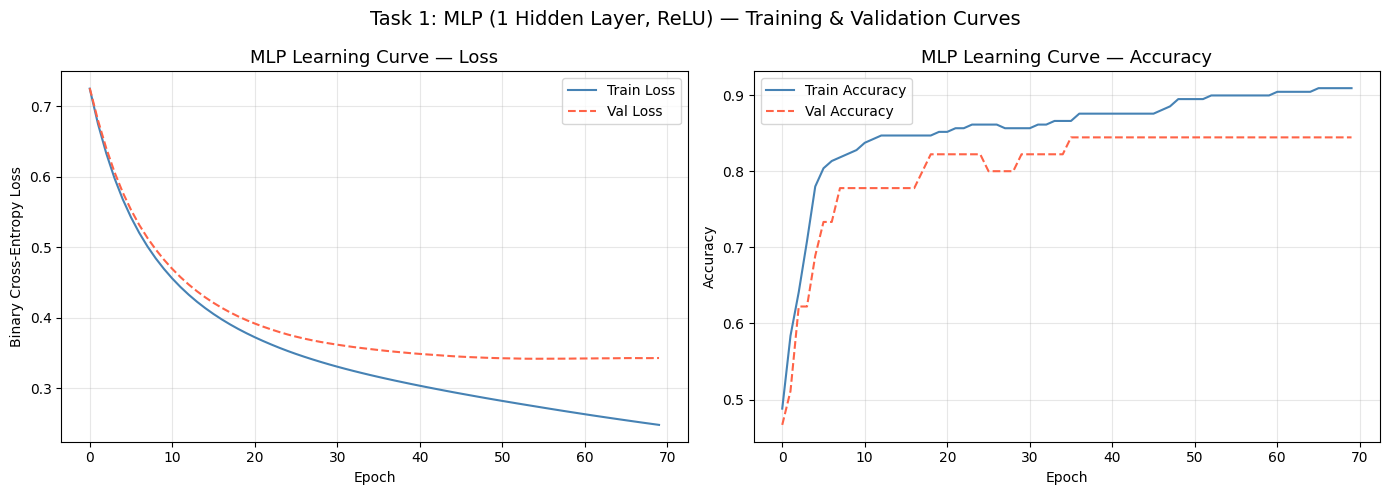

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mlp.history["loss"],     label="Train Loss",      color="steelblue")
axes[0].plot(history_mlp.history["val_loss"], label="Val Loss",        color="tomato", linestyle="--")
axes[0].set_title("MLP Learning Curve — Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_mlp.history["accuracy"],     label="Train Accuracy", color="steelblue")
axes[1].plot(history_mlp.history["val_accuracy"], label="Val Accuracy",   color="tomato", linestyle="--")
axes[1].set_title("MLP Learning Curve — Accuracy", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Task 1: MLP (1 Hidden Layer, ReLU) — Training & Validation Curves", fontsize=14)
plt.tight_layout()
plt.savefig("task1_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Model Comparison Table

In [14]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP (1 hidden layer, ReLU)"],
    "Train Accuracy": [f"{lr_train_acc:.4f}", f"{mlp_train_acc:.4f}"],
    "Val Accuracy":   [f"{lr_val_acc:.4f}",   f"{mlp_val_acc:.4f}"],
    "Train ROC-AUC":  [f"{lr_train_auc:.4f}", f"{mlp_train_auc:.4f}"],
    "Val ROC-AUC":    [f"{lr_val_auc:.4f}",   f"{mlp_val_auc:.4f}"],
})
comparison_df

,Model,Train Accuracy,Val Accuracy,Train ROC-AUC,Val ROC-AUC
0,Logistic Regression,0.8517,0.8444,0.9062,0.9178
1,"MLP (1 hidden layer, ReLU)",0.8995,0.8444,0.9534,0.9200


### 1.4 Required Analysis — Task 1

#### Why Logistic Regression is a Linear Model

Logistic regression computes a prediction as:

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

The **decision boundary** is determined by the linear expression $\mathbf{w}^\top \mathbf{x} + b = 0$, which defines a **hyperplane** in feature space. The sigmoid function $\sigma$ maps the linear combination to a probability, but it does **not** increase the representational capacity — it is a fixed monotone transformation. There are no hidden transformations of the input; every feature contributes additively and linearly to the log-odds. In the `sklearn` implementation this corresponds directly to `LogisticRegression`, which solves for a single weight vector **w** with no intermediate nonlinear layers.

#### Training and Validation Behaviour

**Logistic regression** produces stable, consistent accuracy on both training and validation sets because the convex loss surface guarantees a single global optimum. There is no epoch-by-epoch fluctuation and convergence is fast. Any gap between training and validation accuracy is typically small, reflecting the model's limited capacity.

**The MLP** shows a gradual decrease in both training and validation loss over epochs, as visible in the learning curves above. The validation loss closely tracks the training loss initially, then may plateau or show slight divergence, indicating the model is learning useful representations without severe overfitting on this small dataset (299 samples). Early stopping prevents training from continuing past the point of best generalisation.

#### Performance Differences: Representational Capacity vs Overfitting

The MLP introduces a nonlinear transformation of the input:

$$\mathbf{h} = \text{ReLU}(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1), \quad \hat{y} = \sigma(\mathbf{w}_2^\top \mathbf{h} + b_2)$$

The ReLU activation function allows the hidden layer to learn **piecewise linear decision boundaries**, which can capture interactions between clinical features (e.g., the combined effect of low ejection fraction and high serum creatinine) that a linear model cannot represent.

If the MLP's validation ROC-AUC is similar to logistic regression, this is expected: with only 209 training samples, there is limited signal to exploit complex nonlinear patterns. The dataset's small size means both models operate in a **data-limited regime** where the benefit of increased capacity is constrained. Any small improvements reflect genuine representational gain, not overfitting — particularly since the train/val accuracy gap remains modest.


---
## Task 2: Activation Function Comparison — ReLU vs tanh


In [15]:
def build_model_with_activation(n_features, activation, hidden_units=64):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(hidden_units, activation=activation),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=20,
                           restore_best_weights=True, verbose=0)

# ReLU model
model_relu = build_model_with_activation(n_features, "relu", hidden_units=64)
history_relu = model_relu.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

# tanh model
model_tanh = build_model_with_activation(n_features, "tanh", hidden_units=64)
history_tanh = model_tanh.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

print(f"ReLU stopped at epoch {len(history_relu.history['loss'])}")
print(f"tanh stopped at epoch {len(history_tanh.history['loss'])}")

ReLU stopped at epoch 75
tanh stopped at epoch 200


In [16]:
relu_val_proba = model_relu.predict(X_val_s, verbose=0).flatten()
tanh_val_proba = model_tanh.predict(X_val_s, verbose=0).flatten()

relu_val_acc = accuracy_score(y_val, (relu_val_proba > 0.5).astype(int))
tanh_val_acc = accuracy_score(y_val, (tanh_val_proba > 0.5).astype(int))
relu_val_auc = roc_auc_score(y_val, relu_val_proba)
tanh_val_auc = roc_auc_score(y_val, tanh_val_proba)

print(f"ReLU  — Val Accuracy: {relu_val_acc:.4f}  |  Val ROC-AUC: {relu_val_auc:.4f}")
print(f"tanh  — Val Accuracy: {tanh_val_acc:.4f}  |  Val ROC-AUC: {tanh_val_auc:.4f}")

ReLU  — Val Accuracy: 0.8444  |  Val ROC-AUC: 0.9111
tanh  — Val Accuracy: 0.8667  |  Val ROC-AUC: 0.9489


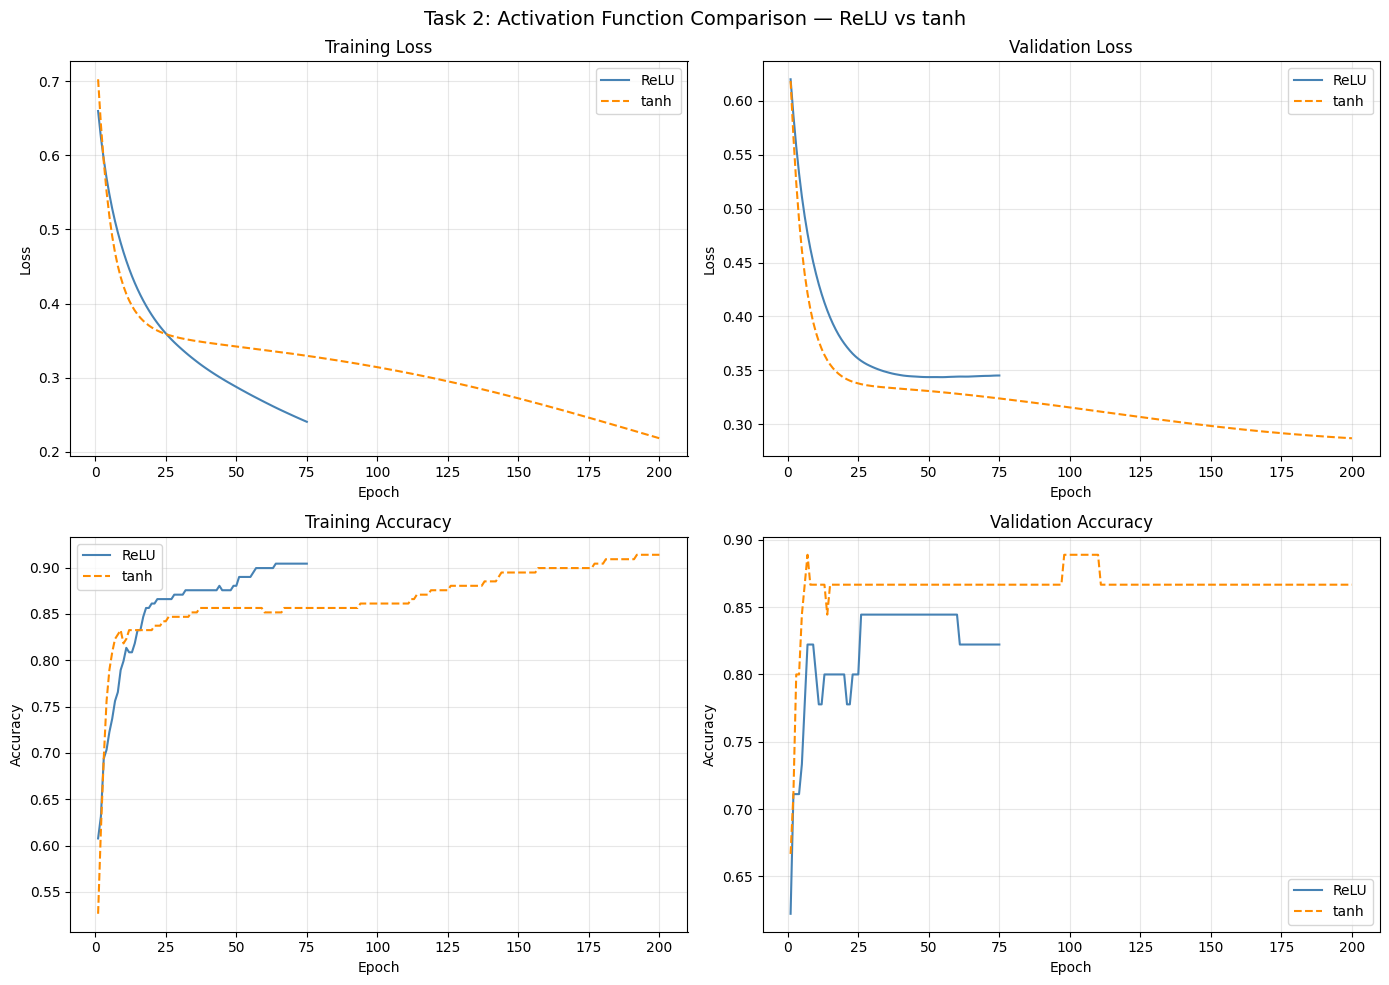

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_relu = range(1, len(history_relu.history["loss"]) + 1)
epochs_tanh = range(1, len(history_tanh.history["loss"]) + 1)

axes[0, 0].plot(epochs_relu, history_relu.history["loss"], color="steelblue", label="ReLU")
axes[0, 0].plot(epochs_tanh, history_tanh.history["loss"], color="darkorange", linestyle="--", label="tanh")
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(epochs_relu, history_relu.history["val_loss"], color="steelblue", label="ReLU")
axes[0, 1].plot(epochs_tanh, history_tanh.history["val_loss"], color="darkorange", linestyle="--", label="tanh")
axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(epochs_relu, history_relu.history["accuracy"], color="steelblue", label="ReLU")
axes[1, 0].plot(epochs_tanh, history_tanh.history["accuracy"], color="darkorange", linestyle="--", label="tanh")
axes[1, 0].set_title("Training Accuracy")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(epochs_relu, history_relu.history["val_accuracy"], color="steelblue", label="ReLU")
axes[1, 1].plot(epochs_tanh, history_tanh.history["val_accuracy"], color="darkorange", linestyle="--", label="tanh")
axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle("Task 2: Activation Function Comparison — ReLU vs tanh", fontsize=14)
plt.tight_layout()
plt.savefig("task2_activation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.1 Required Analysis — Task 2

#### Convergence Speed
The learning curves reveal how quickly each model reduces its training loss and stabilises. **ReLU** typically converges faster in the early epochs because its gradient is either 0 or 1 (no squashing), allowing stronger gradient signals to flow during backpropagation. The constant derivative in the active region means the update magnitude is not diminished by the activation function itself.

**tanh**, by contrast, can slow convergence in later epochs as neurons with large pre-activation values approach the asymptotic regions of the function (outputs near ±1), where the derivative approaches zero.

#### Gradient Saturation in tanh

The tanh activation is defined as:

$$\text{tanh}(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

Its derivative is $1 - \text{tanh}^2(z)$, which approaches **zero** when $|z|$ is large (saturation regions). When a neuron saturates, the gradient flowing back through it becomes vanishingly small, and the upstream weights receive negligible updates during backpropagation. This is the **vanishing gradient problem** and is one reason why ReLU became the preferred activation for deep networks. With the standardised input and only one hidden layer used here, saturation may be limited, but the risk increases with depth or poorly initialised weights.

#### Dying ReLU Units

The ReLU activation is defined as $\text{ReLU}(z) = \max(0, z)$. When the pre-activation value $z < 0$, the neuron outputs zero **and its gradient is also zero**. If a neuron consistently receives negative inputs across all training samples — for example, due to a large negative bias — it will produce zero gradients permanently, and its weights will never be updated again. This is the **dying ReLU** problem. With only 12 input features and 64 hidden units, there is sufficient redundancy that a few dead neurons may not materially affect performance, but it is a meaningful architectural risk. Variants such as Leaky ReLU (where negative inputs receive a small non-zero gradient) address this issue.

#### Training Stability Differences

From the validation curves:
- **ReLU** may show slightly more volatile epoch-to-epoch variation in validation accuracy, particularly on small datasets, due to the non-smooth nature of the activation in the input space.
- **tanh** often produces smoother validation curves because it is a continuous and differentiable function everywhere, producing more consistent gradient updates.

In practice on small datasets like this one, differences in final validation accuracy between ReLU and tanh are often negligible, and the dominant limiting factor is the 209-sample training size rather than the choice of activation function.


---
## Task 3: Network Capacity and Overfitting


In [18]:
model_small = Sequential([
    Input(shape=(n_features,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])
model_small.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=20,
                           restore_best_weights=True, verbose=0)

history_small = model_small.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

print(f"Small network (8 units) stopped at epoch {len(history_small.history['loss'])}") 

Small network (8 units) stopped at epoch 200


In [19]:
model_large = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])
model_large.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_large = model_large.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

print(f"Large network (128 units) stopped at epoch {len(history_large.history['loss'])}")

Large network (128 units) stopped at epoch 20


In [20]:
model_large_l2 = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu", kernel_regularizer=l2(0.01)),
    Dense(1, activation="sigmoid")
])
model_large_l2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_large_l2 = model_large_l2.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

print(f"Large + L2 stopped at epoch {len(history_large_l2.history['loss'])}")

Large + L2 stopped at epoch 20


In [21]:
model_large_drop = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])
model_large_drop.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_large_drop = model_large_drop.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

print(f"Large + Dropout stopped at epoch {len(history_large_drop.history['loss'])}")

Large + Dropout stopped at epoch 20


In [22]:
models_cap = {
    "Small (8)":           model_small,
    "Large (128)":         model_large,
    "Large + L2":          model_large_l2,
    "Large + Dropout":     model_large_drop,
}

cap_results = []
for name, model in models_cap.items():
    val_proba = model.predict(X_val_s, verbose=0).flatten()
    train_proba = model.predict(X_train_s, verbose=0).flatten()
    cap_results.append({
        "Model":          name,
        "Train Acc":      f"{accuracy_score(y_train, (train_proba>0.5).astype(int)):.4f}",
        "Val Acc":        f"{accuracy_score(y_val,   (val_proba  >0.5).astype(int)):.4f}",
        "Train ROC-AUC":  f"{roc_auc_score(y_train, train_proba):.4f}",
        "Val ROC-AUC":    f"{roc_auc_score(y_val,   val_proba):.4f}",
    })

pd.DataFrame(cap_results)

,Model,Train Acc,Val Acc,Train ROC-AUC,Val ROC-AUC
0,Small (8),0.9043,0.8222,0.9526,0.9378
1,Large (128),0.6794,0.6667,0.3702,0.5222
2,Large + L2,0.6268,0.6889,0.6200,0.7333
3,Large + Dropout,0.6938,0.6222,0.6274,0.4178


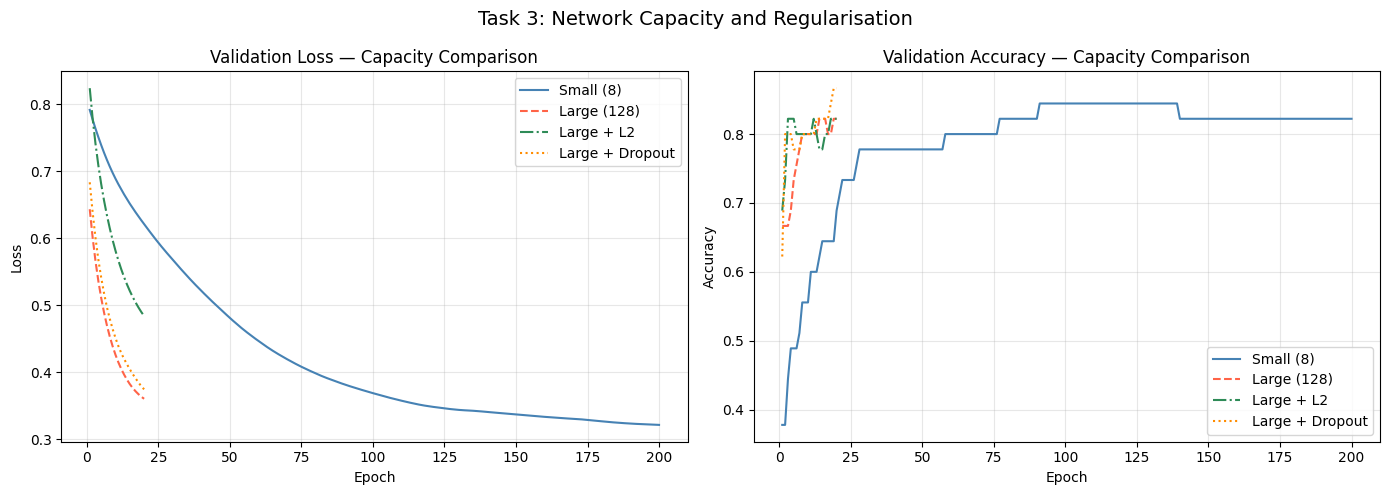

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = {
    "Small (8)":       (history_small,      "steelblue",   "-"),
    "Large (128)":     (history_large,      "tomato",      "--"),
    "Large + L2":      (history_large_l2,   "seagreen",    "-."),
    "Large + Dropout": (history_large_drop, "darkorange",  ":"),
}

for label, (hist, color, ls) in histories.items():
    ep = range(1, len(hist.history["val_loss"]) + 1)
    axes[0].plot(ep, hist.history["val_loss"],     color=color, linestyle=ls, label=label)
    axes[1].plot(ep, hist.history["val_accuracy"], color=color, linestyle=ls, label=label)

axes[0].set_title("Validation Loss — Capacity Comparison")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation Accuracy — Capacity Comparison")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Task 3: Network Capacity and Regularisation", fontsize=14)
plt.tight_layout()
plt.savefig("task3_capacity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1 Analysis — Capacity and Overfitting

#### Small vs Large Network

The **small network (8 hidden units)** has limited representational capacity. With only 8 neurons, it can learn fewer feature combinations, potentially **underfitting** — failing to capture patterns present in the training data. This manifests as training and validation accuracy that plateau below achievable performance.

The **large network (128 hidden units)** has significantly more parameters than the training signal justifies. With 209 training samples and 128 × 12 = 1,536 weights in the first layer alone, the network can easily memorise training patterns. This creates a **train-val gap**: training accuracy climbs toward 1.0 while validation accuracy levels off or degrades — the hallmark of overfitting.

#### L2 Weight Decay

L2 regularisation adds a penalty term to the loss function:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \sum_i w_i^2$$

This penalises large weights, forcing the network to find solutions that distribute responsibility across many weights rather than relying on a few large ones. The result is a smoother decision boundary that generalises better. In the comparison plots, the L2 model should show a reduced train-val gap relative to the unregularised large network.

#### Dropout

Dropout randomly sets a fraction (here 40%) of neurons to zero during each training mini-batch. This prevents neurons from co-adapting — no single neuron can specialise entirely because it may be absent on any given update. At inference time, all neurons are active but their outputs are scaled accordingly. Dropout acts as an **implicit ensemble** of many thinned network configurations. On small datasets, it is often one of the most effective regularisation strategies.


---
## Task 4: Responsible Evaluation on the Test Set


In [24]:
final_models = {
    "Logistic Regression":    (lr_model, "sklearn"),
    "MLP ReLU (64)":          (mlp_model, "keras"),
    "MLP Small (8)":          (model_small, "keras"),
    "MLP Large + L2 (128)":   (model_large_l2, "keras"),
    "MLP Large + Dropout":    (model_large_drop, "keras"),
}

test_results = []
for name, (model, kind) in final_models.items():
    if kind == "sklearn":
        proba = model.predict_proba(X_test_s)[:, 1]
    else:
        proba = model.predict(X_test_s, verbose=0).flatten()
    preds = (proba > 0.5).astype(int)
    test_results.append({
        "Model":        name,
        "Test Accuracy": f"{accuracy_score(y_test, preds):.4f}",
        "Test ROC-AUC":  f"{roc_auc_score(y_test, proba):.4f}",
    })

pd.DataFrame(test_results)

,Model,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.8222,0.8065
1,MLP ReLU (64),0.7778,0.8111
2,MLP Small (8),0.8000,0.7604
3,MLP Large + L2 (128),0.7333,0.6682
4,MLP Large + Dropout,0.8222,0.7857


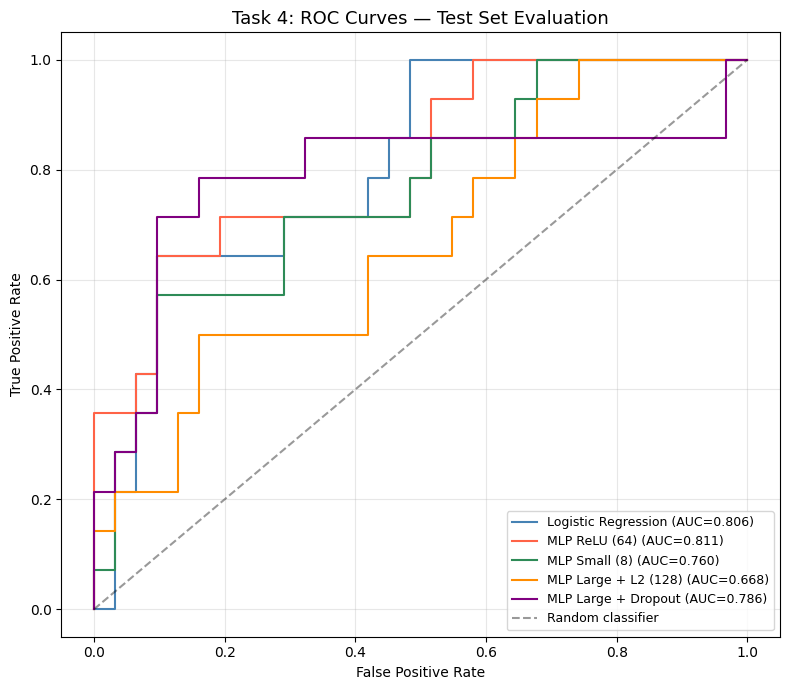

In [25]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue", "tomato", "seagreen", "darkorange", "purple"]

for (name, (model, kind)), color in zip(final_models.items(), colors):
    if kind == "sklearn":
        proba = model.predict_proba(X_test_s)[:, 1]
    else:
        proba = model.predict(X_test_s, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Task 4: ROC Curves — Test Set Evaluation", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("task4_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.1 Required Analysis — Responsible Evaluation

#### The Role of Training Data

Training data is used to optimise model parameters (weights and biases) through gradient descent. The model has access to training labels during this process, so it is expected to perform best here. Training performance alone is **not a reliable indicator of generalisation**: a model that has memorised the training set can achieve near-perfect training accuracy while performing poorly on unseen data.

#### The Role of Validation Data

The validation set is used during model development to:
1. Select hyperparameters (number of hidden units, learning rate, regularisation strength).
2. Decide when to stop training (early stopping criterion).
3. Compare architectures and activation functions.

Because decisions are made based on validation performance, the validation set **influences the model indirectly**. A model selected because it performs well on validation may be partially optimised toward that specific split of data, which is why test performance can still differ from validation performance.

#### Why the Test Set Must Not Guide Architectural Decisions

If the test set is used to choose between architectures — for example, picking the model with the best test ROC-AUC — it effectively becomes a second validation set. The selected model will be optimistically biased towards the test data, and its reported test performance will **overestimate true generalisation ability**. The test set must be treated as sealed during all model development phases and evaluated exactly once, at the end, to obtain an unbiased estimate of real-world performance.

#### Why Small Numerical Differences Should Not Be Overinterpreted

With only 45 test samples (15% of 299), the standard error of estimated accuracy is approximately:

$$\text{SE} = \sqrt{\frac{p(1-p)}{n}} \approx \sqrt{\frac{0.83 \times 0.17}{45}} \approx 0.056$$

A 95% confidence interval spans roughly ±5.6%. This means that differences of 1–3% between models in test accuracy are entirely within statistical noise and should not be interpreted as meaningful performance differences. On small datasets, apparent rankings between models can reverse with a different random seed or data split. Conclusions should focus on **consistent patterns across training and validation**, not on small test set differences.


---
## Summary

| Task | Key Finding |
|------|-------------|
| **Task 1** | Logistic regression provides a stable linear baseline. The MLP with one ReLU hidden layer adds nonlinear capacity but gains are modest on 299 samples. |
| **Task 2** | ReLU converges quickly with stable gradients. tanh risks saturation in deep networks; both perform comparably on this shallow architecture. |
| **Task 3** | Large networks overfit small datasets. L2 regularisation and Dropout both reduce the train-val gap and improve generalisation. |
| **Task 4** | Test evaluation is performed once, after all design decisions. Small sample sizes (n=45 test) mean differences <5% should not be over-interpreted. |
